#### 환경 조성

In [1]:
# # 코랩 모드
# import os
# import unicodedata

# if "raw.tar.gz" not in os.listdir():
#     !wget https://github.com/wonbywondev/ML-DL/releases/download/data-v3/raw.tar.gz
# else:
#     print("raw.tar.gz 있음")

# if not os.path.exists("/content/raw"):
#     !tar -xzvf raw.tar.gz -C /content

# ROOT_DIR = "/content"
# DATA_DIR = os.path.join(ROOT_DIR, "raw")

# train_json_path = os.path.join(DATA_DIR, "일상생활및구어체_한영_train_set.json")
# val_json_path = os.path.join(DATA_DIR, "일상생활및구어체_한영_valid_set.json")

# train_json_path = unicodedata.normalize("NFC", train_json_path)
# val_json_path = unicodedata.normalize("NFC", val_json_path)

In [2]:
# 로컬 모드
import os

ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "data")

train_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_train_set.json")
val_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_valid_set.json")

In [ ]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


Matplotlib is building the font cache; this may take a moment.


---

# 목표

번역기 만들기

In [4]:
import json

with open(train_json_path, "r", encoding="utf-8") as f:
    TRAIN_DATA = json.load(f)

TRAIN_DATA = TRAIN_DATA["data"]

### 샘플 출력

In [5]:
import random

rand_idx = random.randint(1, len(TRAIN_DATA)) - 1

TRAIN_DATA[rand_idx]

{'sn': 'KFDS0620122150134333',
 'data_set': '일상생활및구어체',
 'domain': '일상생활',
 'subdomain': '음식',
 'ko_original': '>5위에요?',
 'ko': '>5위에요?',
 'mt': "It's 5th place?",
 'en': '>5th place?',
 'source_language': 'ko',
 'target_language': 'en',
 'word_count_ko': 1,
 'word_count_en': 2,
 'word_ratio': 2.0,
 'file_name': '음식_KFDS.xlsx',
 'source': 'SBS',
 'license': 'open',
 'style': '구어체',
 'included_unknown_words': False,
 'ner': None}

ner은 Named Entity Recognition. 꼭 살려둬야 한다.

In [6]:
print("[데이터 속성 고유값]")

unique_dict = {key: (set() if key != "ner" else list()) for key in TRAIN_DATA[0].keys()}


for i, dict_ in enumerate(TRAIN_DATA):   
    for key, value in dict_.items():
        if key == "ner":
            unique_dict[key].append(value if value else "null")
        else:
            unique_dict[key].add(value if value else "null")


for key, value in unique_dict.items():
    print(f"· {key}: {len(value)}개")

    if len(value) < 20:
        print(f"    - {value}")

[데이터 속성 고유값]
· sn: 1200000개
· data_set: 1개
    - {'일상생활및구어체'}
· domain: 3개
    - {'해외고객과의채팅', '해외영업', '일상생활'}
· subdomain: 11개
    - {'숙박,음식점', '도소매유통', '예약', '구매', '연구개발,과학기술', '여행', '기계장비,의료정밀', '부동산', '금융,보험', '음식', '정보통신'}
· ko_original: 1059799개
· ko: 1059798개
· mt: 1015045개
· en: 1024329개
· source_language: 1개
    - {'ko'}
· target_language: 1개
    - {'en'}
· word_count_ko: 56개
· word_count_en: 73개
· word_ratio: 673개
· file_name: 18개
    - {'INTSAL_RLST.xlsx', '예약_KRSS.xlsx', 'CUSCHA_RLST.xlsx', 'INTSAL_EGKG.xlsx', 'INTSAL_DSUT.xlsx', '여행_KTOS.xlsx', '음식_KFDS.xlsx', 'CUSCHA_MCHO.xlsx', 'CUSCHA_DSUT.xlsx', 'CUSCHA_FNIN.xlsx', 'INTSAL_JBTS.xlsx', '구매_KPUS.xlsx', 'CUSCHA_STRS.xlsx', 'INTSAL_STRS.xlsx', 'INTSAL_FNIN.xlsx', 'CUSCHA_EGKG.xlsx', 'INTSAL_MCHO.xlsx', 'CUSCHA_JBTS.xlsx'}
· source: 2개
    - {'크라우드소싱', 'SBS'}
· license: 1개
    - {'open'}
· style: 1개
    - {'구어체'}
· included_unknown_words: 1개
    - {'null'}
· ner: 1200000개


### 중복치

domain, subdomain, 내용이 일치하는 데이터를 언어별로 삭제.

번역본끼리 한 쌍, 원본끼리 한 쌍으로 묶는다.

In [7]:
import pandas as pd

useless_list = [
    "sn", "data_set", "license", "source", "style", 
    "included_unknown_words", "file_name", 
    "source_language", "target_language"
    ]

useful_list = [column for column in list(TRAIN_DATA[0].keys()) if column not in useless_list]

train_df = pd.DataFrame(TRAIN_DATA, columns=useful_list)

In [8]:
lang_list = [["ko_original", "en"], ["ko", "mt"]]

for lang in lang_list:
    train_df = train_df.drop_duplicates(["domain", "subdomain"] + lang, keep="first")

print(f"· 중복 제거 후 데이터: {len(train_df)}개")

· 중복 제거 후 데이터: 1080887개


### 극단치

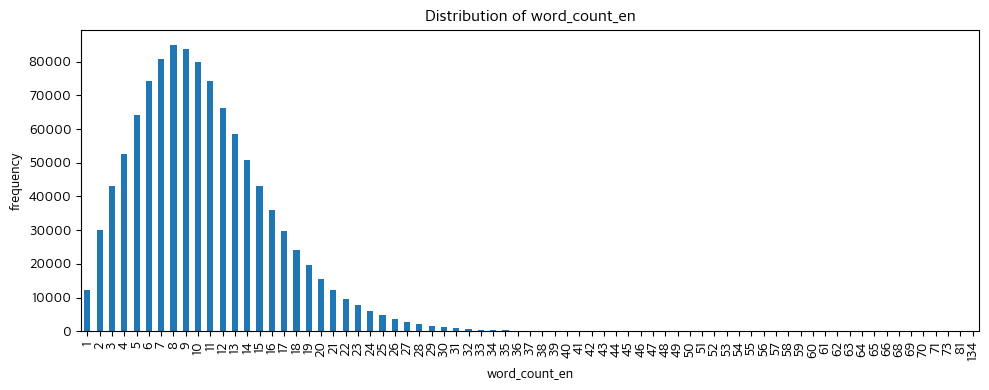

In [9]:
counts = train_df["word_count_en"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_en")
plt.ylabel("frequency")
plt.title("Distribution of word_count_en")
plt.tight_layout()
plt.show()

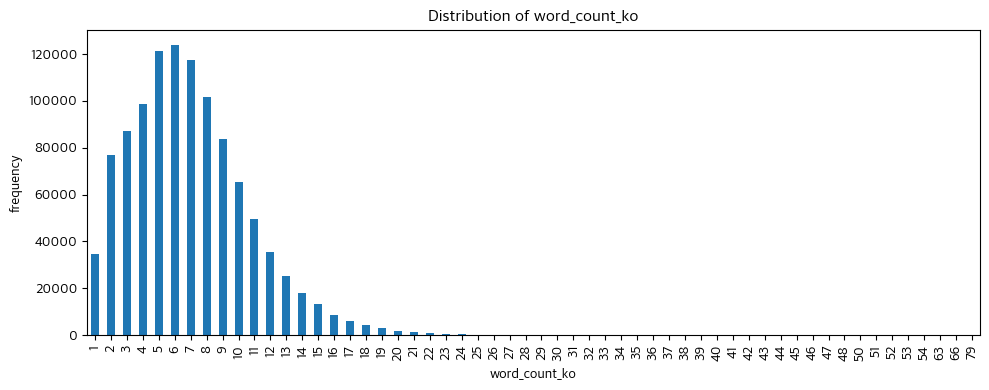

In [10]:
counts = train_df["word_count_ko"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_ko")
plt.ylabel("frequency")
plt.title("Distribution of word_count_ko")
plt.tight_layout()
plt.show()

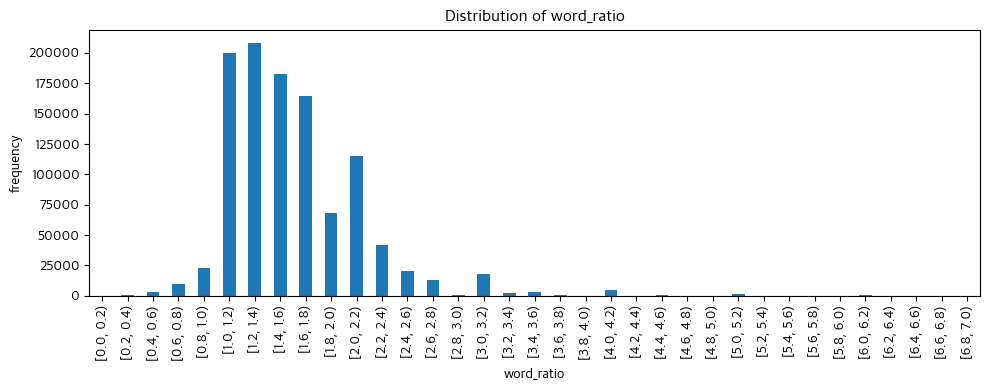

In [11]:
import numpy as np

bins = np.arange(0, 7.2, 0.2)
groups = pd.cut(train_df["word_ratio"], bins=bins, right=False)

counts = groups.value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_ratio")
plt.ylabel("frequency")
plt.title("Distribution of word_ratio")
plt.tight_layout()

plt.show()

In [12]:
train_df = train_df[train_df["word_count_ko"] <= 25]
train_df = train_df[train_df["word_count_en"] <= 35]
train_df = train_df[train_df["word_ratio"] <= 3.5]

### 도메인 맵핑

In [13]:
domain_map = {value: i for i, value in enumerate(unique_dict["domain"])}
subdomain_map = {value: i for i, value in enumerate(unique_dict["subdomain"])}

train_df["domain"] = train_df['domain'].map(domain_map)
train_df["subdomain"] = train_df['subdomain'].map(subdomain_map)

In [14]:
train_df = train_df.reset_index().drop("index", axis=1)

In [15]:
TRAIN_DATA = train_df.to_dict("index")
print(f"· 가공 후 데이터: {len(TRAIN_DATA)}개")

· 가공 후 데이터: 1070866개


In [ ]:
rand_idx = random.randint(1, len(TRAIN_DATA)) - 1

print("[가공 후 샘플 출력]")
print(f"key: {rand_idx}")
TRAIN_DATA[rand_idx]


[가공 후 샘플 출력]
key: 217519


{'domain': 0,
 'subdomain': 1,
 'ko_original': '귀사의 분위기는 어떤가요?',
 'ko': '귀사의 분위기는 어떤가요?',
 'mt': 'How is the atmosphere of your company?',
 'en': 'How is the atmosphere of your company?',
 'word_count_ko': 3,
 'word_count_en': 7,
 'word_ratio': 2.333,
 'ner': None}

# 실험 계획

1. ner 데이터를 이용하여 다른 데이터에도 적용한다.